In [1]:
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import pandas as pd
import matplotlib.pyplot as plt

# Research Question

### Does pitting during a stage-ending caution (vs. staying out to collect stage points) correlate with better final finishing position, and does this differ by track type?

# 2026 Race Schedule

### Full Schedule Results

In [2]:
# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2026
series_id = 1
race_id = 5543


schedule = Schedule(year, series_id)
schedule.data.head()


Fetching data for Year:2026 Series:1


,race_id,series_id,race_season,race_name,race_type_id,restrictor_plate,track_id,track_name,date_scheduled,race_date,...,inspection_complete,playoff_round,is_qualifying_race,qualifying_race_no,qualifying_race_id,has_qualifying,winner_driver_id,pole_winner_laptime,scheduled_at,track_type
0,5593,1,2026,Cook Out Clash at Bowman Gray,2,False,159,Bowman Gray Stadium,2026-02-01T20:00:00,2026-02-04T18:00:00,...,True,0,False,0,-1,False,4070.0,None,2026-02-04 18:00:00+00:00,short track
1,5594,1,2026,America 250 Florida Duel at DAYTONA,2,True,105,Daytona International Speedway,2026-02-12T19:00:00,2026-02-12T19:00:00,...,True,0,False,0,-1,False,3859.0,None,2026-02-12 19:00:00+00:00,superspeedway
2,5595,1,2026,America 250 Florida Duel at DAYTONA,2,True,105,Daytona International Speedway,2026-02-12T20:45:00,2026-02-12T20:45:00,...,True,0,False,0,-1,False,4062.0,None,2026-02-12 20:45:00+00:00,superspeedway
3,5596,1,2026,DAYTONA 500,1,True,105,Daytona International Speedway,2026-02-15T13:30:00,2026-02-15T14:30:00,...,True,0,False,0,-1,False,4065.0,None,2026-02-15 14:30:00+00:00,superspeedway
4,5597,1,2026,Autotrader 400,1,True,111,Atlanta Motor Speedway,2026-02-22T15:00:00,2026-02-22T15:00:00,...,True,0,False,0,-1,False,4065.0,None,2026-02-22 15:00:00+00:00,intermediate


### Finished Races

In [3]:
schedule.get_finished_races()

,race_id,series_id,race_season,race_name,race_type_id,restrictor_plate,track_id,track_name,date_scheduled,race_date,...,inspection_complete,playoff_round,is_qualifying_race,qualifying_race_no,qualifying_race_id,has_qualifying,winner_driver_id,pole_winner_laptime,scheduled_at,track_type
31,5625,1,2026,Enjoy Illinois 300,1,False,45,World Wide Technology Raceway,2026-09-13T15:00:00,2026-09-13T15:00:00,...,True,1,False,0,-1,False,4030.0,None,2026-09-13 15:00:00+00:00,intermediate
30,5624,1,2026,Cook Out Southern 500,1,False,4,Darlington Raceway,2026-09-06T17:00:00,2026-09-06T17:00:00,...,True,1,False,0,-1,False,4153.0,None,2026-09-06 17:00:00+00:00,intermediate
29,5623,1,2026,Coke Zero Sugar 400,1,True,105,Daytona International Speedway,2026-08-29T19:30:00,2026-08-29T19:30:00,...,True,0,False,0,-1,False,4070.0,None,2026-08-29 19:30:00+00:00,superspeedway
28,5627,1,2026,Dollar Tree 301,1,False,138,New Hampshire Motor Speedway,2026-08-23T14:00:00,2026-08-23T15:00:00,...,True,0,False,0,-1,False,4023.0,None,2026-08-23 15:00:00+00:00,short track
27,5622,1,2026,Cook Out 400,1,False,26,Richmond Raceway,2026-08-15T19:00:00,2026-08-15T19:00:00,...,True,0,False,0,-1,False,3859.0,None,2026-08-15 19:00:00+00:00,short track
26,5620,1,2026,Iowa Corn 350 Powered by Ethanol,1,False,206,Iowa Speedway,2026-08-09T15:30:00,2026-08-09T15:30:00,...,True,0,False,0,-1,False,4368.0,None,2026-08-09 15:30:00+00:00,short track
25,5619,1,2026,Brickyard 400 presented by PPG,1,False,123,Indianapolis Motor Speedway,2026-07-26T14:00:00,2026-07-26T14:00:00,...,True,0,False,0,-1,False,4387.0,None,2026-07-26 14:00:00+00:00,superspeedway
24,5618,1,2026,Window World 450,1,False,177,North Wilkesboro Speedway,2026-07-19T19:00:00,2026-07-19T19:00:00,...,True,0,False,0,-1,False,3859.0,None,2026-07-19 19:00:00+00:00,short track
23,5615,1,2026,Quaker State 400 Available at Walmart,1,True,111,Atlanta Motor Speedway,2026-07-12T19:00:00,2026-07-12T19:00:00,...,True,0,False,0,-1,False,4023.0,None,2026-07-12 19:00:00+00:00,intermediate
22,5616,1,2026,eero 400,1,False,39,Chicagoland Speedway,2026-07-05T18:00:00,2026-07-05T17:00:00,...,True,0,False,0,-1,False,4228.0,None,2026-07-05 17:00:00+00:00,unknown


# Daytona 500 Data

Used this section to figure our how the data was structured due to it being in it's own python library without a visible structure.

### Race Results

In [31]:
race = Race(2026, 1, 5596, reload=False)

results_df = race.results.results
results_df = results_df[results_df['starting_position'] != 0]

results_df = results_df.drop(columns=[
    "manufacturer",
    "sponsor",
    "team",
    "team_id",
    "qualifying_position",
    "qualifying_speed",
    "laps_completed",
    "points",
    "playoff_points",
    "qualifying_order"
])
print(results_df.shape)
results_df.head()





Reading from Cache for 2026-1-5596
Fetching Data for 2026-1-5596
(41, 5)


,driver_id,driver_name,car_number,starting_position,finishing_position
4,4065,Tyler Reddick,45,26,1
5,3888,Ricky Stenhouse Jr.,47,16,2
6,3859,Joey Logano,22,3,3
7,4062,Chase Elliott,9,4,4
8,1816,Brad Keselowski,6,9,5


In [7]:
race = Race(2026, 1, 5596, reload=True)
race.results.cautions

Fetching Data for 2026-1-5596


,start_lap,end_lap,caution_type,comment,flag_state
0,6,11,Accident,"#4, 24, 40, 45, 66, 78 Incident Turn 4",2
1,67,71,Competition,Stage 1 Conclusion,2
2,86,91,Accident,"#1, 3, 19, 34, 40, 51, 54, 67, 88 Incident Fro...",2
3,125,135,Accident,"#1, 2, 5, 8, 11, 12, 22, 24, 34, 35, 38, 40, 4...",2
4,193,196,Accident,"#11, 20 Incident Frontstretch",2


Cleaned a data frame just to show drivers who pitted during stage one and on what lap.

In [8]:
pit_stops = race.telemetry.pit_stops
cautions = race.results.cautions

# filter to the stage/competition cautions specifically
stage_cautions = cautions[cautions['caution_type'].str.contains('Competition', case=False, na=False)]

# Stage 1's caution specifically
stage_1_caution = stage_cautions.iloc[0]
stage_1_laps = range(stage_1_caution['start_lap'], stage_1_caution['end_lap'] + 1)

stage_1_pits = pit_stops[pit_stops['lap'].isin(stage_1_laps)]

stage_1_pits = stage_1_pits.drop(columns=[
    "manufacturer",
    "pit_in_flag_status",
    "pit_out_flag_status",
    "pit_in_race_time",
    "pit_out_race_time",
    "total_duration",
    "box_stop_race_time",
    "box_leave_race_time",
    "left_rear_tire_changed",
    "right_front_tire_changed",
    "right_rear_tire_changed",
    "previous_lap_time",
    "next_lap_time",
    "pit_in_rank",
    "pit_out_rank",
    "positions_gained_lost",
    "driver_id",
    "car_number",
    "pit_stop_duration",
    "in_travel_duration",
    "out_travel_duration",
    "pit_stop_type",
    "left_front_tire_changed"
])

with pd.option_context('display.max_rows', None):
    display(stage_1_pits)

print(stage_1_pits.shape)

,driver_name,lap
129,Zane Smith,67
130,Austin Cindric,67
131,Ryan Blaney,67
132,Carson Hocevar,67
133,Daniel Suarez,67
134,Chris Buescher,67
135,Michael McDowell,67
136,Ryan Preece,67
137,Alex Bowman,67
138,Chase Briscoe,67


(61, 2)


Another way to see clearly how many drivers pitted vs stayed out.

In [9]:
pit_stops = race.telemetry.pit_stops
cautions = race.results.cautions
results_df = race.results.results  # or your cleaned version with non-starters dropped

# get all Competition (stage) cautions
stage_cautions = cautions[cautions['caution_type'].str.contains('Competition', case=False, na=False)]

# build the full list of laps covered by any of these cautions
stage_caution_laps = []
for _, row in stage_cautions.iterrows():
    stage_caution_laps.extend(range(row['start_lap'], row['end_lap'] + 1))

# find which drivers pitted during those laps
pitted_drivers = set(pit_stops[pit_stops['lap'].isin(stage_caution_laps)]['driver_name'])

# split your results into two groups
pitted_df = results_df[results_df['driver_name'].isin(pitted_drivers)]
stayed_out_df = results_df[~results_df['driver_name'].isin(pitted_drivers)]

print(f"Pitted: {len(pitted_df)} drivers")
print(f"Stayed out: {len(stayed_out_df)} drivers")

Pitted: 39 drivers
Stayed out: 6 drivers


# Data Visualizations

Created a range of races to use for the data visualizations. Used all the races finished up until the completion of this project.

In [12]:
race_ids = range(5593, 5624)

excluded = [5593, 5595, 5601, 5608]
race_ids = [r for r in range(5593, 5624) if r not in excluded]

Chosing only the laps people pitted due to stage cautions.

In [13]:
import shutil
shutil.rmtree('.cache', ignore_errors=True)

all_pitted = []
all_stayed_out = []
failed_races = []

for race_id in race_ids:
    try:
        race = Race(2026, 1, race_id, reload=True)
    except Exception as e:
        print(f"Skipping race {race_id}: failed to load ({e})")
        failed_races.append(race_id)
        continue

    pit_stops = race.telemetry.pit_stops
    cautions = race.results.cautions

    if pit_stops.empty or 'lap' not in pit_stops.columns:
        print(f"Skipping race {race_id}: pit_stops missing or malformed")
        failed_races.append(race_id)
        continue

    if cautions.empty or 'caution_type' not in cautions.columns:
        print(f"Skipping race {race_id}: cautions missing or malformed")
        failed_races.append(race_id)
        continue

    results_df = race.results.results
    results_df = results_df[results_df['starting_position'] != 0]

    stage_cautions = cautions[cautions['caution_type'].str.contains('Competition', case=False, na=False)]

    stage_caution_laps = []
    for _, row in stage_cautions.iterrows():
        stage_caution_laps.extend(range(row['start_lap'], row['end_lap'] + 1))

    pitted_drivers = set(pit_stops[pit_stops['lap'].isin(stage_caution_laps)]['driver_name'])

    pitted_df = results_df[results_df['driver_name'].isin(pitted_drivers)].copy()
    stayed_out_df = results_df[~results_df['driver_name'].isin(pitted_drivers)].copy()

    pitted_df['race_id'] = race_id
    stayed_out_df['race_id'] = race_id

    all_pitted.append(pitted_df)
    all_stayed_out.append(stayed_out_df)

print(f"Failed/skipped races: {failed_races}")
print(f"Successful races: {len(all_pitted)}")

if all_pitted:
    pitted_all = pd.concat(all_pitted, ignore_index=True)
    stayed_out_all = pd.concat(all_stayed_out, ignore_index=True)
else:
    print("No races succeeded — check failed_races for the underlying errors.")

Fetching Data for 2026-1-5594
Fetching Data for 2026-1-5596
Fetching Data for 2026-1-5597
Fetching Data for 2026-1-5598
Fetching Data for 2026-1-5599
Fetching Data for 2026-1-5600
Fetching Data for 2026-1-5602
Fetching Data for 2026-1-5603
Fetching Data for 2026-1-5604
Fetching Data for 2026-1-5605
Fetching Data for 2026-1-5606
Fetching Data for 2026-1-5607
Fetching Data for 2026-1-5609
Fetching Data for 2026-1-5610
Fetching Data for 2026-1-5611
Fetching Data for 2026-1-5612
Fetching Data for 2026-1-5613
Fetching Data for 2026-1-5614
Fetching Data for 2026-1-5615
Fetching Data for 2026-1-5616
Fetching Data for 2026-1-5617
Fetching Data for 2026-1-5618
Fetching Data for 2026-1-5619
Fetching Data for 2026-1-5620
Fetching Data for 2026-1-5621
Fetching Data for 2026-1-5622
Fetching Data for 2026-1-5623
Failed/skipped races: []
Successful races: 27


Visualization plotting the average finish of drivers who pitted during the stage caution vs who stayed out during the stage cautions per race.

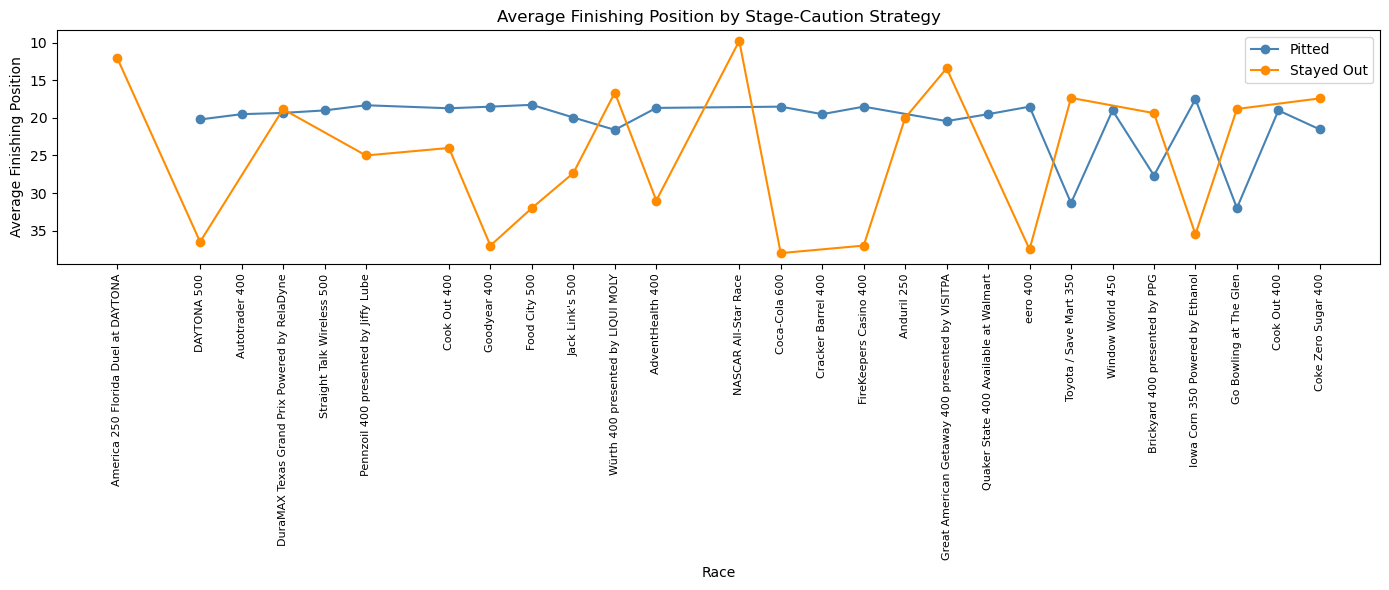

In [ ]:
schedule = Schedule(2026, 1).data

# build id -> name lookup
race_name_map = dict(zip(schedule['race_id'], schedule['race_name']))

all_race_ids = sorted(set(pitted_avg_by_race.index) | set(stayed_out_avg_by_race.index))
race_labels = [race_name_map.get(rid, str(rid)) for rid in all_race_ids]

plt.figure(figsize=(14, 6))
plt.plot(pitted_avg_by_race.index, pitted_avg_by_race.values,
         marker='o', label='Pitted', color='steelblue')
plt.plot(stayed_out_avg_by_race.index, stayed_out_avg_by_race.values,
         marker='o', label='Stayed Out', color='darkorange')

plt.xlabel('Race')
plt.ylabel('Average Finishing Position')            
plt.title('Average Finishing Position by Stage-Caution Strategy')

plt.xticks(all_race_ids, race_labels, rotation=90, fontsize=8)

plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

Filtering the races by track type.

In [21]:
schedule = Schedule(2026, 1).data

track_type_labels = {1: 'Superspeedway', 2: 'Intermediate', 3: 'Short Track'}

track_type_map = dict(zip(schedule['race_id'], schedule['race_type_id'].map(track_type_labels)))

pitted_all['track_type'] = pitted_all['race_id'].map(track_type_map)
stayed_out_all['track_type'] = stayed_out_all['race_id'].map(track_type_map)

# average finishing position by track type, for each group
pitted_by_track = pitted_all.groupby('track_type')['finishing_position'].mean()
stayed_out_by_track = stayed_out_all.groupby('track_type')['finishing_position'].mean()

print(pitted_by_track)
print(stayed_out_by_track)

track_type
Superspeedway    19.29931
Name: finishing_position, dtype: float64
track_type
Intermediate     10.627119
Superspeedway    19.822727
Name: finishing_position, dtype: float64


In [27]:
track_type_map = dict(zip(schedule['race_id'], schedule['track_type']))

pitted_all['track_type'] = pitted_all['race_id'].map(track_type_map)
stayed_out_all['track_type'] = stayed_out_all['race_id'].map(track_type_map)

# drop unknown/non-points races from both groups
pitted_all = pitted_all[pitted_all['track_type'] != 'unknown']
stayed_out_all = stayed_out_all[stayed_out_all['track_type'] != 'unknown']

pitted_by_track = pitted_all.groupby('track_type')['finishing_position'].mean()
stayed_out_by_track = stayed_out_all.groupby('track_type')['finishing_position'].mean()

print(pitted_by_track)
print(stayed_out_by_track)

track_type
intermediate     19.150538
road course      22.941176
short track      18.595349
superspeedway    20.196629
Name: finishing_position, dtype: float64
track_type
intermediate     14.206897
road course      18.297872
short track      30.500000
superspeedway    17.575000
Name: finishing_position, dtype: float64


Visualization showing the position difference of drivers who pitted vs staying out per track type.

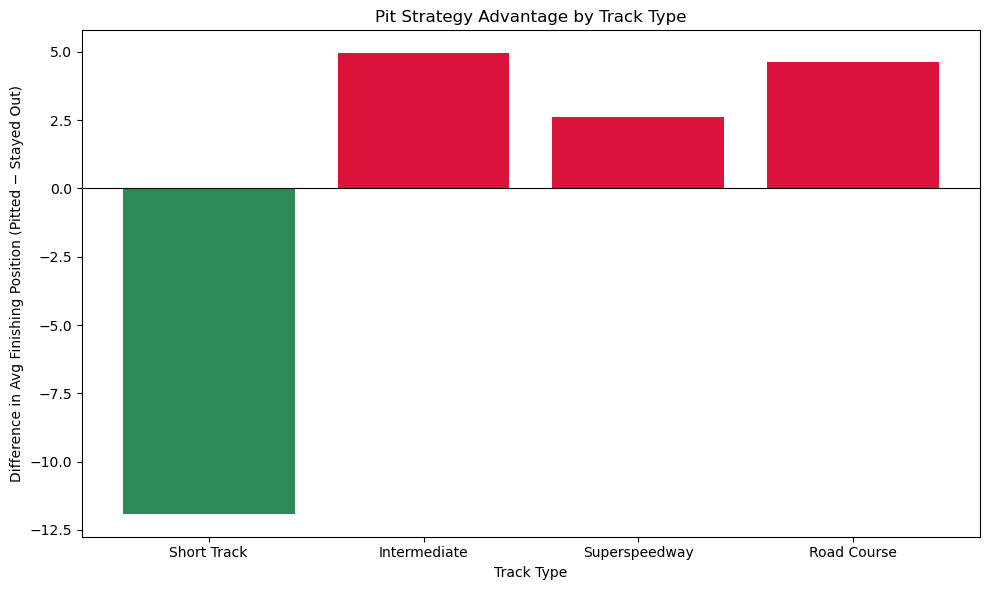

In [29]:
diff_by_track = pitted_by_track - stayed_out_by_track
diff_by_track = diff_by_track.reindex(track_types)  # keep consistent order

plt.figure(figsize=(10, 6))
colors = ['crimson' if v > 0 else 'seagreen' for v in diff_by_track.values]
plt.bar([t.title() for t in track_types], diff_by_track.values, color=colors)

plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Track Type')
plt.ylabel('Difference in Avg Finishing Position (Pitted − Stayed Out)')
plt.title('Pit Strategy Advantage by Track Type')
plt.tight_layout()
plt.show()

Showing the sample sizes of each variable.

In [30]:
print(pitted_all['track_type'].value_counts())
print(stayed_out_all['track_type'].value_counts())

track_type
intermediate     279
short track      215
superspeedway    178
road course       17
Name: count, dtype: int64
track_type
road course      94
superspeedway    80
intermediate     58
short track       6
Name: count, dtype: int64
